# Data pipelines

[Matt Graham](https://matt-graham.github.io)
[](https://orcid.org/0000-0001-9104-7960)
(Centre for Advanced Research Computing)  
[Anastasis
Georgoulas](https://uk.linkedin.com/in/anastasis-georgoulas-265b12167)
[](https://orcid.org/0000-0001-7187-5443)

## Introduction

We are going to step back a bit from the details of fitting specific
classes of machine learning models as covered in the earlier lectures,
and instead look at some of the wider issues involved in managing the
data and model outputs we accumulate during data science projects. This
comes under the umbrella of what is sometimes termed machine learning
operations or MLOps for short.

The sorts of questions we will consider include

-   How to store and access datasets hosted remotely.
-   How to manage the multiple versions of datasets and models we
    produce during a typical project.
-   And how to ensure our analyses are reproducible.

Importantly we will also cover some useful tools that can help
streamlines our workflows and ensure they can be reproduced by others.

We will begin by considering how we structure our overall workflows,
including not just the model fitting process but the stages that feed in
and out of this.

## Learning outcomes

-   Recognize that model training is **just one part** of machine
    learning workflows.
-   Describe key **typical stages of data pipelines**.
-   Identify the benefits of defining data pipelines
    **programmatically**.
-   Explain the importance of the **FAIR principles** for data
    management.

## Data preparation

Typically before we train any machine learning model there will steps we
need to go through to get the data into the format required to fit the
model, and potentially also to get hold of the data in the first place.

For example,

-   we may need to access the data from some remote repository,
-   the data may need cleaning or other preprocessing,
-   we may need to transform the raw data to generate the features
    required for training the model,
-   we may need to serve the data in a particular way for it to be
    consumable by the model,
-   once the model is fitted we may wish to share it with others.

## Pipelines



The overall sequences of steps involved in such a typical machine
learning workflow is sometimes called a *data pipeline*, with related
terms such as *extract-transform-load* or ETL also being used.

We can visualise this as a data flow graph as shown here. To ensure
reproducibility ideally all stages in the pipeline should be defined
programmatically through code rather than requiring manual actions.
We’ll now go through and explain what might be involved in each of these
stages, and use running example of analysing historical climate records
data to illustrate an concrete example of a data pipeline.

## Accessing data

Commonly the first step in any data science project will be to get hold
of the data we will be analysing, unless we happen to have collected it
ourselves. This typically happens in a variety of different ways, for
example:

-   we get sent a data file by a colleague.
-   we pull the data from some web service.
-   we might run a scraper to extract data from a website
-   or we might execute a query to a database we have access to.

It will often be the case that we in fact have to combine data from
multiple different sources. We will discuss some of the intricacies of
querying data from a database in a later lecture.

A unifying aspect of most of these examples is that the data is hosted
remotely on a different computer. How specifically we access it will
depend on the details of the remote host, the format of the data and its
sizes, however importantly the steps to access the data can often be
defined programatically.

## Example: Downloading climate data

To give an example of how we might access data programmatically, we will
consider how to download a set of [historical global climate
records](https://github.com/awslabs/open-data-docs/tree/main/docs/noaa/noaa-ghcn)
from an open dataset hosted on *Simple Storage Service* (S3) that is
part of the *Amazon Web Services* (AWS) cloud offering.

In this example we will use [the Python standard library module
`urllib.request`](https://docs.python.org/3/library/urllib.request.html)
which allows programmatically accessing data hosted on the web via
*hypertext transfer protocol* (HTTP). In more complex cases, for example
where access to an S3 bucket requires authentication, [the Python
package
`boto3`](https://boto3.amazonaws.com/v1/documentation/api/latest/index.html)
is a dedicated Python package for interacting with AWS services
programmatically.

The particular data we will be using are the climate records from the
year 1800, which are held in an S3 bucket `noaa-ghcn-pds` in tabular
format as a *comma separated variable* (CSV) file, which has been
compressed using [gzip](https://en.wikipedia.org/wiki/Gzip). Python has
a built-in module `gzip` which can be used to uncompress the file and we
will use Pandas to read in the data to a dataframe.

In [2]:
import urllib.request
import gzip
import pandas

data_url = "https://noaa-ghcn-pds.s3.amazonaws.com/csv.gz/1800.csv.gz"
with urllib.request.urlopen(data_url) as response:
    with gzip.open(response, "rb") as f:
        input_data = pandas.read_csv(
            f, usecols=range(4), names=["station", "date", "quantity", "value"]
        )
display(input_data.head())

## Preprocessing

Typically getting access to the data we need is only the first step,
with often the raw data needing to be preprocessed before use. This
might be for example because,

-   there are errors in the data,
-   the dimensionality of each data point or number of data points is
    too large for us to be able to use directly,
-   the data contains irrelevant information for our analysis,
-   the variables in the raw data do not directly correspond to
    quantities of interest which need to be derived from the raw data,
-   there may be outliers or imbalances in the dataset that might affect
    the fitting of some models.

The sorts of preprocessing steps we might perform to address these
issues include,

-   removing problematic values from the data,
-   filtering the data to a smaller subset or augmenting it by repeating
    samples.

This process is sometimes referred to as *data cleaning*, and is a vital
and often overlooked stage in data pipelines. While such cleaning steps
can be performed manually, tools such as
[OpenRefine](https://openrefine.org/) have been developed to help
automate the process.

## Example: filtering climate records

Returning to our running climate data example, at the end of the
previous stage of our pipeline we had the data loaded into a dataframe
`input_data` containing climate records for the year 1800 for multiple
different land-observation stations. We will assume we are interested in
fitting a model to daily temperature range recorded for a single
station. This will mean we will need to preprocess the input data to
filter for the records associated with a particular station.

Specifically here we will look for the records recorded at a station in
Milan, Italy and use the [Pandas `DataFrame.query`
method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html)
to perform the filtering.

In [3]:
preprocessed_data = input_data.query(
    'station == "ITE00100554" and quantity in ["TMIN", "TMAX"]'
)
display(preprocessed_data.head())

## Transforming

Once we have performed any necessary cleaning and preprocessing of the
data, while closer to have data in the form necessary for model fitting,
often we will need go through further stages of data processing first. A
very common requirement is to generate features suitable for training
the model from the variables present in the raw data.

## Example: transforming to temperature range time series

Going back to our running example again, after the preprocessing step we
have a dataframe `preprocessed_data` containing records of all the daily
minimum and maximum temperature measurements, in tenths of a degree
Celsius, for each day in 1800 for the station of interest in Milan. Our
aim is to fit a model to the daily temperature range in degrees Celsius
against the date, and so we need to process the dataframe to produce the
required variates and covariates for regression.

In [4]:
pivoted_data = preprocessed_data.pivot(
    index="date", columns="quantity", values="value"
)
pivoted_data.index = pandas.to_datetime(pivoted_data.index, format="%Y%m%d")
display(pivoted_data.head())

In [5]:
transformed_data = pandas.DataFrame(
    {"temperature_range": (pivoted_data.TMAX - pivoted_data.TMIN) / 10}
)
display(transformed_data.head())

## Serving

The code to trained a model will often require data to be provided in a
particular format. After we have finished preprocessing the data we
therefore still need to ensure the data is *served* to the model in the
correct format for consumption by the model.



The data can be served to a model in a variety of ways - while file
based input-output is common, in other cases we might for example make
the data available via a web service. They key point is the data needs
to be in the format required to feed to the model.

Libraries such as Pandas provide a variety of functions for reading from
and writing to data in a range of commonly used formats - for example
JSON or CSV files.

``` python
import pandas as pd
df = pd.read_json('my_data.json')
# ...Perform any transformations...
df.to_csv('my_ready_data.csv')
```

## Example: serving for scikit-learn

In previous lectures you have seen that scikit-learn requires that the
training data provided to regression models is formatted as a features
matrix with rows corresponding to the numeric features of each training
data point and a one-dimensional target array containing the target
values for each training data point.

For our running example we will convert the measurement dates to integer
days of the year as the input features, so that they are of a numeric
type as required. For the target outputs we will use the temperature
ranges.

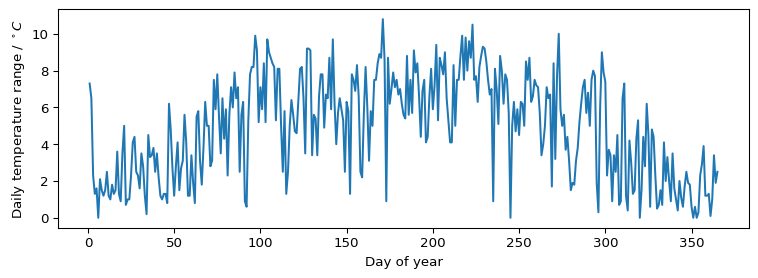

In [6]:
import matplotlib.pyplot as plt

X_train = transformed_data.index.day_of_year.array[:, None]
y_train = transformed_data.temperature_range.array
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_train, y_train)
ax.set(xlabel="Day of year", ylabel=r"Daily temperature range / $^\circ C$")
fig.tight_layout()

## Model fitting

When we finally have the data served in the format required for feeding
to the model we are ready to begin training, or potentially prediction
using an existing trained model. This could involve any of the different
model types and Python packages such as scikit-learn and TensorFlow,
that have been covered in the preceding lectures.

As an aside, it is important to note that both scikit-learn and
TensorFlow internally make use of the concept of data pipelines when
building models.

Where we consider the dividing line between the model and other data
pipeline stages may therefore in practice not always be that clear cut
as the model itself may be a composition of multiple components,
including steps we might consider as feature extraction or
transformations. For example, commonly the earlier layers of deep neural
network models are considered as feature extractors feeding into a
regressor or classifier in the final layer.

## Example: fitting a periodic spline

Again returning to our running climate data example, we will illustrate
fitting the noisy temperature range time series data we previously
observed with a [spline
model](https://en.wikipedia.org/wiki/Spline_(mathematics)) in
scikit-learn. Splines are a flexible way of describing smooth
relationships between variables using piecewise polynomials constrained
to ensure smoothness at the join points. They are parametrized by a set
of knot points defining how the input space is partitioned, and a
positive integer degree specifying the exponent of the highest order
polynomial term used.

As we saw when plotting the data, there appears to be an underlying
*seasonal* trend in the time series, and so we will additionally enforce
that the model is *periodic* with period one year. We will use a spline
with 7 knots, corresponding to partitioning the input time interval into
6 roughly bimonthly intervals, with this allowing capturing a smooth
representation of the overall seasonal trends without overfitting to the
*noisy* daily variation.

In [7]:
import numpy
from sklearn import pipeline, preprocessing, linear_model

model = pipeline.make_pipeline(
    preprocessing.SplineTransformer(
        degree=3,
        knots=numpy.linspace(1, 365, 7)[:, None],
        extrapolation="periodic"
    ),
    linear_model.Ridge()
)
model.fit(X_train, y_train)

We can visualise the fitted model’s predictions over the input range to
check they look reasonable using `matplotlib`

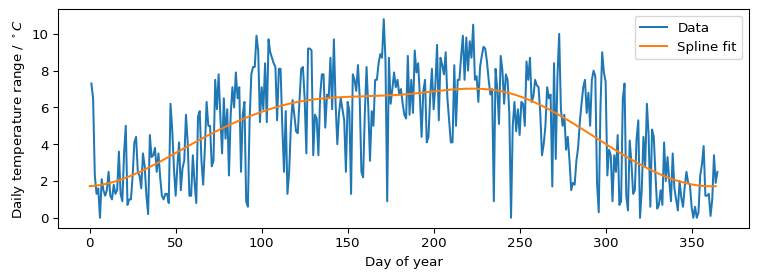

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_train, y_train, model.predict(X_train))
ax.set(xlabel="Day of year", ylabel=r"Daily temperature range / $^\circ C$")
ax.legend(["Data", "Spline fit"])
fig.tight_layout()

## Publishing

Once we have trained our model or used it to produce predictions, our
job is still often not yet done. The model itself and the outputs we
generate using it can be considered as new data to be shared with others
to allow them to reproduce our analyses and reuse the results in their
own analysis.

We might therefore wish to host our model or model outputs on a platform
that allows others to access them. A simple option would be to simply
place the files on cloud storage service such as the Amazon Web Services
Simple Storage Service we encountered previously. While a viable route
for giving others access to the model files themselves, in general to
ensure our data is amenable to reuse by others as possible we need to do
some further work.

One particular route that can be worth considering is to use a
specialised repositories for hosting research data and other digital
assets such as [Zenodo](https://zenodo.org/) or institutional
equivalents such as the UCL Research Data Repository. Compared to
generic cloud storage services these offer more features for helping to
ensure the way we share our data aligns with what are called the FAIR
principles of findability, accessibility, interoperability and
reusability, that we will cover in more detail shortly.

## Publishing data

A key consideration when releasing and data is the format it will be
stored in. Typically it is better to distribute data either in generic
widely supported open data formats - for example *comma separated
variable* (CSV) files for tabular data or *JavaScript Object Notation*
(JSON) files for structured data, or in a formats that are standard to a
particular field, for example NetCDF files for geoscientific data or
DICOM for medical imaging data. Likewise it is best to avoid where
possible non-open file formats that require proprietary software to read
such as Excel workbooks or MATLAB data files, to ensure the data is as
usable by as wide an audience as possible.

A very important point is that as well as publishing the data itself,
you should also distribute the data with descriptive **metadata** which
describes for example, the provenance of the data, that is how it was
generated and where any data that fed into it came from, and documents
what is included within the data and how to interpret it.

## FAIR principles

When publishing data or other digital assets, a useful framework to
follow are what are called the [**FAIR
principles**](https://www.go-fair.org/fair-principles/), which where
first defined in a research article in Scientific Data by a consortium
of scientists and research organizations in March 2016.

A key consideration underlying the FAIR principles are that the shared
data and metadata should be machine actionable - that is able to be used
with minimal human intervention. The four principles are defined as

-   Findability - the idea that potential users should be able to search
    for a shared data artefact via some index. This is linked to a
    requirement that the data is assigned a unique and persistent global
    identifier so that it can indexed and also refound and referred to
    later, and that it is described with a rich set of metadata that
    facilitate searching.
-   Accessibility - this refers to the principle that how data can be
    accessed must be clearly documented, ideally by allowing use of a
    standardized communication protocol for accessing the data and its
    attached metatdata via its unique global identifier.
-   Interoperability - this encapsulates the need for the shared data
    artefact to be able to be integrated with other data and software. A
    key consideration here is the format in which both the data and any
    attached metadata is distributed.
-   Reusability - the overall aim of the FAIR principles are to
    facilitate reuse of data. This both requires that the data is richly
    described by metadata that explain its provenance and how it is
    structured, but also that the terms of reuse of the data are clearly
    defined using an accessible data usage license.

## Publishing models

We have so far discussed the idea of sharing and publishing data in a
generic sense, but at the beginning of the section we made the point
that the model itself is data that can be shared and published. It might
not be as clear however as for a static data file how this can be
accomplished. There are a variety of different ways however in which we
can share models, each with their own set of strengths and weaknesses.

-   We could build an executable application that allows model outputs
    to be computed for new data and distribute the corresponding
    binaries. While this may be a relatively simple way for other people
    to use your model in some circumstances, typically an executable
    will be specific to a particular operating system or hardware
    architecture, meaning either we limit the range of users who can use
    the model or have to deal with building and distributing
    applications for a multitude of platforms. An executable application
    will also typically give limited details in itself of how a model is
    structured, make it difficult to adapt the model and depending on
    the interface exposed may make it difficult to reuse the model
    within other software.
-   One relatively popular option for deploying machine learning models
    is to create a web service which allows users to query the model
    with their own data via some web-based interface. This will
    typically be a more technically involved option than distributing an
    executable application but has the benefit of being inherently cross
    platform, with many programming languages and analysis software
    providing functionality to interact with web services. Similar to an
    executable application, publishing model as a web service will mean
    that while it can be used as blackbox which gives outputs for
    provided inputs, it will typically not allow users to understand the
    structures and assumptions underlying the model and adapt it to
    their own applications.
-   Another option is to distribute a container, for example using
    software such as Docker, which has a resuable image of both the code
    for running your model but also all of the dependencies required for
    other to use the model within a virtual machine on their own
    computer. This has the advantage of being inherently cross platform,
    but can require more effort or expertise from the user in terms of
    being familiar with use of container technology, and a whole system
    image will typically be much slower to download than just a single
    executable application.
-   One of the simplest approaches, and the one we show a concrete
    example of here, is to *serialize* the model to a file that can then
    be used to load the model object on a different computer or the same
    machine in the future. This requires support within the framework
    used for building the model for performing such serialization, but
    has the advantage of resulting in a lightweight artefact that is
    simple to share and can be typically be loaded on any platform that
    the underlying framework is supported on.

## Model serialization

Within the Python ecosystem, there is a built-in module `pickle` which
can serialize a range of both built-in and third party data types to
file. Importantly for us scikit-learn models support serializing with
`pickle` and so this represents a simple way of sharing trained models
as static files.

One important restriction however is that while pickle files can be
loaded, with some restrictions, across Python versions and across
different operating systems, for the pickled object to correctly load
and reproduce the behaviour of the original object, at the very least
the Python environment it is being loaded in must have all of the
packages defining any datatypes used in the pickled objects installed,
and ideally should have exactly the same versions of these packages to
ensure reproducibility. This can be facilitated by for example including
a text file which defines pinned versions of all the package versions
installed in the environment used to produce a pickle along with the
pickle file itself.

## Example: serializing trained model

In [9]:
import pickle

with open("trained_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("trained_model.pkl", "rb") as f:
    saved_model = pickle.load(f)
saved_model

## Summary

That brings us to end of this first lecture. To summarize what we have
covered so far

-   We have introduced the concept of a data pipeline which encapsulates
    all of the stages which are involved in accessing and preprocessing
    the data which feed in to a model along with publishing the any
    outputs from the model or the model itself.
-   A key point that we tried to illustrate via our running climate data
    example is that ideally all these stages can be defined
    programatically with this giving an explicit record of the
    operations that went in to building a model and allowing these steps
    to easily reproduced by others.
-   One point that we touched on early in the lecture is that because of
    both the increasingly large size of datasets but also prevalence of
    technologies for sharing data, being able to access data which is
    held remotely is becoming more and important for data science
    workflows and so it is useful to be aware of tools and packages that
    help facilitate this.

In the next lecture we introduce a tool, data version control, which can
help us in automating some of these tasks around accessing remote data
and keeping track of the outputs of data pipeline stages.